In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np


In [2]:
#data
from sklearn.datasets import load_iris

iris = load_iris()

## Support Vector Machines
Svm is a binary and multiclass model that classfy data based on his features ranges.it detect pattners on features of each class and save the decision boundary of each class at a specific range for each of his feature.

Let's explore it in pratice;


- Svm is very sensitive to features due his pattner detection between them.so we will use **StandardScaler** to ajust it.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

#models:
from sklearn.svm import LinearSVC,SVC

#test,avaliate:
from sklearn.model_selection import train_test_split

Svc_ovr = Pipeline([
    ('scaler',StandardScaler()),
    ('Linearsvc',LinearSVC(loss='hinge',C=1))
])

Svc_ovo = Pipeline ([
    ('scaler',StandardScaler()),
    ('Svc',SVC(kernel='linear'))
])

Scaler = Pipeline([
    ('sca',StandardScaler())])


#data:
x_iris_data = pd.DataFrame(iris['data'][:,(1,3)]) # sepal width,petal width
y_iris_data = pd.DataFrame((iris['target'] == 1).astype(np.float64)) # versicolor , for smvc one vs rest

y_multiclass_iris = pd.DataFrame(iris['target'].astype(np.float64)) # use this in svmc one vs one

x_iris,x_test,y_iris,y_test = train_test_split(x_iris_data,y_iris_data,random_state=33,test_size=0.2)
x_iris_classes,x_test_cl,y_classes,y_classes_test = train_test_split(x_iris_data,y_multiclass_iris,random_state=22,test_size=0.2)

In [26]:
#training :
Svc_ovo.fit(x_iris_classes,y_classes)
Svc_ovr.fit(x_iris,y_iris)


c:\Users\augusto\.vscode\Data Sci and Ml\Linear_Regression\.venv\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\augusto\.vscode\Data Sci and Ml\Linear_Regression\.venv\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,steps,"[('scaler', ...), ('Linearsvc', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,loss,'hinge'
,dual,'auto'
,tol,0.0001


In [27]:
Scaler.fit(x_iris,y_iris)

,steps,"[('sca', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True


In [28]:
#predicts

svc1=Svc_ovo.predict(Scaler.transform(x_test))
svc2=Svc_ovr.predict(Scaler.transform(x_test_cl))


Text(0, 0.5, 'petal width')

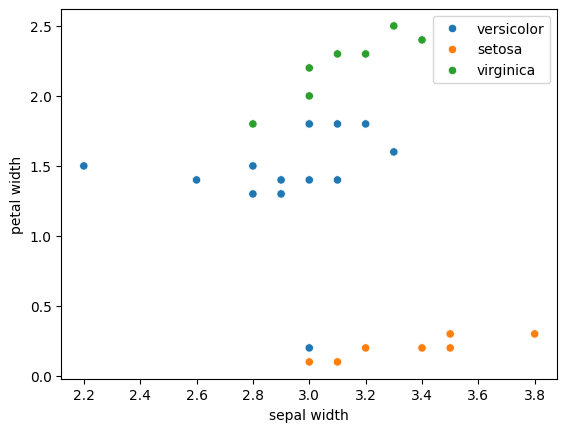

In [30]:
sns.scatterplot(data=x_test,x=x_test[0],y=x_test[1],
        hue=[iris.target_names[i] for i in svc1.astype(int)])
plt.xlabel('sepal width')
plt.ylabel('petal width')

In [34]:
print(y_multiclass_iris)

       0
0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
..   ...
145  2.0
146  2.0
147  2.0
148  2.0
149  2.0

[150 rows x 1 columns]


## Non Linear SVM

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.datasets import make_moons
from sklearn.pipeline import Pipeline


x_m,y_m = make_moons(n_samples=100,noise=0.15)

poly_m = Pipeline([
    ('non_linear_features',PolynomialFeatures(degree=3)),
    ('scaler',StandardScaler()),
    ('model',LinearSVC(C=10,loss='hinge'))
])